In [1]:
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [2]:
import sys
!{sys.executable} -m pip install plotly

In [3]:
with open('../models/minirocket.pkl', 'rb') as f:
    loaded_minirock = pickle.load(f)

with open('../models/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('../models/sgdc.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("Models Loaded")

Models Loaded


In [11]:
# X = np.load("../data/savedData/X_partition3.npy", allow_pickle=True)
# y = np.load("../data/savedData/y_partition3.npy", allow_pickle=True)

# X = np.load("../data/savedData/X_data.npy", allow_pickle=True)
# y = np.load("../data/savedData/y_data.npy", allow_pickle=True)
# regions = np.load("../data/savedData/regions.npy", allow_pickle=True)


In [12]:
# regions = np.load("../data/savedData/regions_partition3.npy", allow_pickle=True)

In [4]:
y_test = np.load("../data/savedData/y_test.npy")
clf_pred = np.load("../data/savedData/y_pred.npy")
probs = np.load("../data/savedData/y_prob.npy")


In [6]:
# print(X.shape)

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# X_mr = loaded_minirock.transform(X)
# X_scale = loaded_scaler.transform(X_mr)
# prob = loaded_model.predict_proba(X_scale)[:, 1]

# # thresh = 0.7
# # preds = (prob >= thresh).astype(int)

# print("t | acc | prec_macro | rec_macro | f1_macro")

for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    
    preds = (probs >= t).astype(int)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro")
    rec = recall_score(y_test, preds, average="macro")
    f1 = f1_score(y_test, preds, average="macro")

    print(f"{t:.1f} | {acc:.4f} | {prec:.4f} | {rec:.4f} | {f1:.4f}")

0.3 | 0.9516 | 0.6167 | 0.8825 | 0.6707
0.4 | 0.9515 | 0.6162 | 0.8806 | 0.6699
0.5 | 0.9515 | 0.6162 | 0.8806 | 0.6699
0.6 | 0.9516 | 0.6163 | 0.8806 | 0.6701
0.7 | 0.9516 | 0.6165 | 0.8806 | 0.6703
0.8 | 0.9517 | 0.6166 | 0.8807 | 0.6705
0.9 | 0.9520 | 0.6171 | 0.8808 | 0.6712


In [14]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# X_mr = loaded_minirock.transform(X)
# X_scale = loaded_scaler.transform(X_mr)
# prob = loaded_model.predict_proba(X_scale)[:, 1]

# # thresh = 0.7
# # preds = (prob >= thresh).astype(int)

# print("t | acc | prec_macro | rec_macro | f1_macro")

# for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    
#     preds = (prob >= t).astype(int)

#     acc = accuracy_score(y, preds)
#     prec = precision_score(y, preds, average="macro")
#     rec = recall_score(y, preds, average="macro")
#     f1 = f1_score(y, preds, average="macro")

#     print(f"{t:.1f} | {acc:.4f} | {prec:.4f} | {rec:.4f} | {f1:.4f}")


t | acc | prec_macro | rec_macro | f1_macro
0.3 | 0.9291 | 0.5911 | 0.6667 | 0.6148
0.4 | 0.9291 | 0.5911 | 0.6667 | 0.6149
0.5 | 0.9291 | 0.5912 | 0.6668 | 0.6150
0.6 | 0.9292 | 0.5913 | 0.6668 | 0.6150
0.7 | 0.9293 | 0.5914 | 0.6668 | 0.6152
0.8 | 0.9294 | 0.5916 | 0.6669 | 0.6153
0.9 | 0.9295 | 0.5916 | 0.6666 | 0.6153


In [11]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     14448
           1       0.24      0.81      0.37       254

    accuracy                           0.95     14702
   macro avg       0.62      0.88      0.67     14702
weighted avg       0.98      0.95      0.96     14702



In [16]:
print(confusion_matrix(y, preds))

[[38963  2123]
 [  876   548]]


In [17]:
print(roc_auc_score(y, prob))

0.8345534435306158


In [18]:
results_df = pd.DataFrame({
    'True_Class': y,
    'Predicted_Class': preds,
    'Flare_Probability': prob
})

results_df["Correct"] = results_df["True_Class"] == results_df["Predicted_Class"]

# print(results_df.head(20))
print(results_df)

false_negatives = results_df[(results_df.True_Class == 1) & (results_df.Predicted_Class == 0)]
false_positives = results_df[(results_df.True_Class == 0) & (results_df.Predicted_Class == 1)]

true_positives = results_df[(results_df.True_Class == 1) & (results_df.Predicted_Class == 1)]
true_negatives = results_df[(results_df.True_Class == 0) & (results_df.Predicted_Class == 0)]

print("False negatives:", len(false_negatives))
print("False positives:", len(false_positives))

print("True positives:", len(true_positives))
print("True negatives:", len(true_negatives))

       True_Class  Predicted_Class  Flare_Probability  Correct
0               1                1       1.000000e+00     True
1               1                1       1.000000e+00     True
2               1                0      2.934130e-226    False
3               1                1       1.000000e+00     True
4               1                1       1.000000e+00     True
...           ...              ...                ...      ...
42505           0                0       0.000000e+00     True
42506           0                0       0.000000e+00     True
42507           0                0       0.000000e+00     True
42508           0                0       6.809146e-13     True
42509           0                0       0.000000e+00     True

[42510 rows x 4 columns]
False negatives: 876
False positives: 2123
True positives: 548
True negatives: 38963


In [19]:
results_df

,True_Class,Predicted_Class,Flare_Probability,Correct
0,1,1,1.000000e+00,True
1,1,1,1.000000e+00,True
2,1,0,2.934130e-226,False
3,1,1,1.000000e+00,True
4,1,1,1.000000e+00,True
...,...,...,...,...
42505,0,0,0.000000e+00,True
42506,0,0,0.000000e+00,True
42507,0,0,0.000000e+00,True
42508,0,0,6.809146e-13,True


In [12]:
import plotly.io as pio

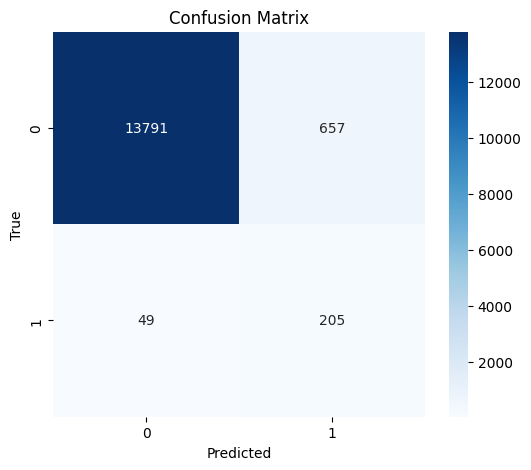

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

conf_mat = confusion_matrix(y_test,preds)

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap="Blues")

plt.xlabel('Predicted')
plt.ylabel("True")
plt.title("Confusion Matrix")

cm_fig=plt.gcf()
plt.show()


In [22]:
from plotly.tools import mpl_to_plotly

In [23]:
# plotly_cm_fig = mpl_to_plotly(cm_fig)
# cm_html=pio.to_html(plotly_cm_fig, full_html=False)
# print(plot_html)

In [14]:
import plotly.express as px
import plotly.io as pio

fig = px.imshow(
    conf_mat,
    text_auto=True,
    color_continuous_scale="Blues"
)

# fig.update_xaxes(tickvals=[0, 1], ticktext=['0', '1'], tickpadding=10)
# fig.update_yaxes(tickvals=[0, 1], ticktext=['0', '1'], tickpadding=10)

fig.update_xaxes(tickmode = 'array', tickvals = [0,1], ticktext= ['0', '1'])
fig.update_yaxes(tickmode = 'array', tickvals = [0,1], ticktext= ['0', '1'])

fig.update_layout(
    title = 'Confusion Matrix',
    xaxis_title='Predicted Label',
    yaxis_title='True Label',
    autosize=True,
    coloraxis_showscale = False,
    margin=dict(l=80, r=20, t=40, b=80)
)


cm_html = pio.to_html(fig, full_html=False, include_plotlyjs='cdn')


In [15]:
with open('../webapp/confusion_matrix.html', 'w') as f:
    f.write(cm_html)

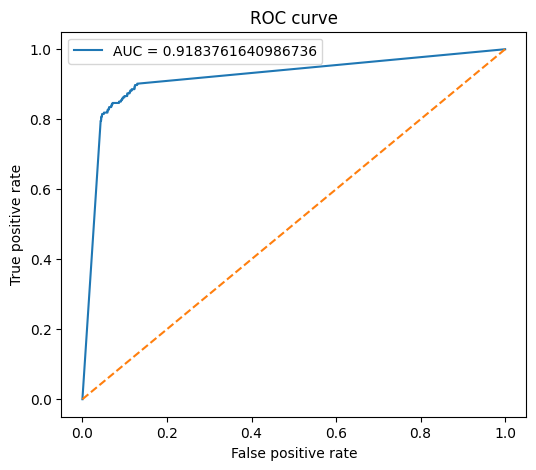

In [16]:
fpr, tpr, thresholds = roc_curve(y_test,probs)
score = roc_auc_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label="AUC = " + str(score))
plt.plot([0,1],[0,1], '--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
roc_fig=plt.gcf()
plt.show()

In [27]:
# plotly_roc_fig = mpl_to_plotly(roc_fig)
# roc_html = pio.to_html(plotly_roc_fig, full_html=False)

In [17]:
import plotly.graph_objects as go
import plotly.io as pio

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC (AUC = {score:.3f})'
))

fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    line=dict(dash='dash'),
    name='Random'
))

fig.update_layout(
    # width=450,
    # height=400,
    autosize= True,
    margin=dict(l=50, r=20, t=40, b=50),
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    title="ROC Curve"
)

roc_html = pio.to_html(fig, full_html=False, include_plotlyjs='cdn')

In [18]:
with open('../webapp/roc_curve.html', 'w') as f:
    f.write(roc_html)